<a href="https://colab.research.google.com/github/mikeshawcode/Mike-Shaw-Data-Analytics-Portfolio/blob/main/Superstore_Dataset_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Superstore Sales Forecast Analysis
**Author:** Mike Shaw  
**Goal:** Predict daily sales for the week of Dec 31, 2018 – Jan 6, 2019 using Meta's Prophet forecasting model.

---
## Approach
1. **Load & Validate** — inspect shape, dtypes, and missing values
2. **Exploratory Data Analysis** — understand sales patterns by time, category, region, and segment
3. **Feature Engineering** — build a clean daily time series
4. **Model Training** — fit Prophet with seasonality and holiday effects
5. **Model Evaluation** — train/test split + cross-validation with MAE, RMSE, MAPE
6. **7-Day Forecast** — produce and interpret the prediction window
7. **Conclusions** — business implications and model limitations

---
## 1. Setup & Data Loading

In [1]:
# Install Prophet (required in Colab)
!pip install prophet --quiet

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load data
folder_path = '/content/drive/My Drive/Superstore Sales Project/'
df = pd.read_csv(folder_path + 'SuperstoreSales.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Mounted at /content/drive
Shape: (9800, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


---
## 2. Data Validation
Before any analysis, confirm data quality: types, nulls, and duplicates. Skipping this step is the most common source of silent bugs in time series forecasting.

In [2]:
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')
df = df.sort_values('Order Date').reset_index(drop=True)

print('--- Data Types ---')
print(df.dtypes)

print('\n--- Missing Values ---')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'No missing values.')

print(f'\n--- Duplicate Rows ---')
print(f'Duplicates: {df.duplicated().sum()}')

print(f'\n--- Date Range ---')
print(f'First order : {df["Order Date"].min().date()}')
print(f'Last order  : {df["Order Date"].max().date()}')
print(f'Span        : {(df["Order Date"].max() - df["Order Date"].min()).days} days')

print(f'\n--- Sales Summary ---')
print(df['Sales'].describe().round(2))

--- Data Types ---
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

--- Missing Values ---
Postal Code    11
dtype: int64

--- Duplicate Rows ---
Duplicates: 0

--- Date Range ---
First order : 2015-01-03
Last order  : 2018-12-30
Span        : 1457 days

--- Sales Summary ---
count     9800.00
mean       230.77
std        626.65
min          0.44
25%         17.25
50%         54.49
75%        210.60
max      22638.48
Name: Sales, dtype: float64


---
## 3. Exploratory Data Analysis
Understanding *what drives* sales before forecasting makes the model more defensible and surfaces anomalies that could skew predictions.

### 3a. Sales by Category, Sub-Category, and Region
Identify which product lines and geographies dominate revenue — important context for explaining forecast swings.

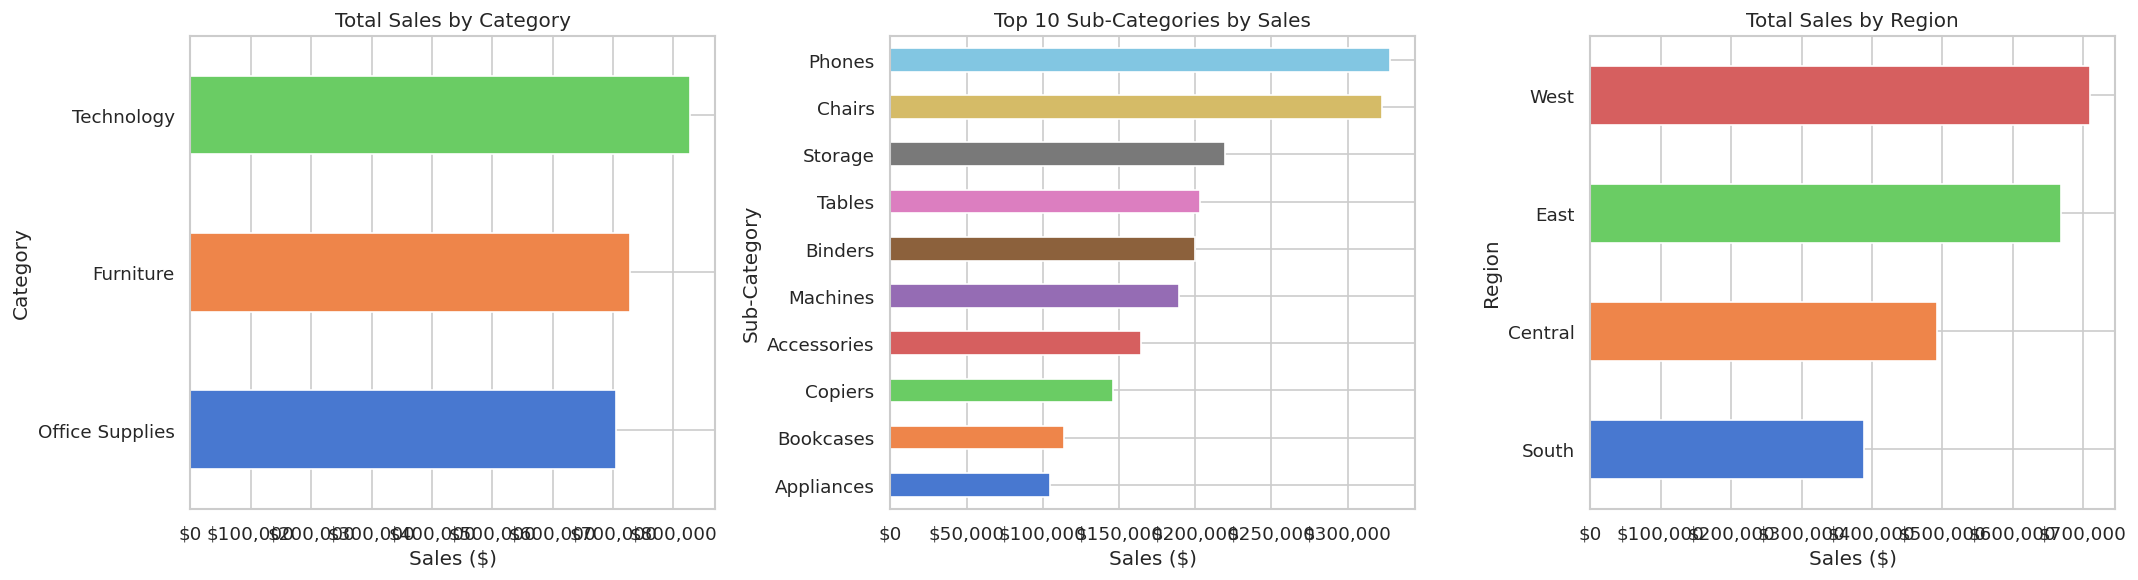

Category share of total sales:
Category
Furniture          32.2
Office Supplies    31.2
Technology         36.6


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
cat_sales.plot(kind='barh', ax=axes[0], color=sns.color_palette('muted', len(cat_sales)))
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Sub-Category (top 10)
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)
subcat_sales.plot(kind='barh', ax=axes[1], color=sns.color_palette('muted', 10))
axes[1].set_title('Top 10 Sub-Categories by Sales')
axes[1].set_xlabel('Sales ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)
region_sales.plot(kind='barh', ax=axes[2], color=sns.color_palette('muted', len(region_sales)))
axes[2].set_title('Total Sales by Region')
axes[2].set_xlabel('Sales ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print('Category share of total sales:')
print((df.groupby('Category')['Sales'].sum() / df['Sales'].sum() * 100).round(1).to_string())

### 3b. Time Patterns
Prophet's power comes from detecting seasonality. Visualizing monthly, day-of-week, quarterly, and year-over-year patterns confirms which seasonal components belong in the model.

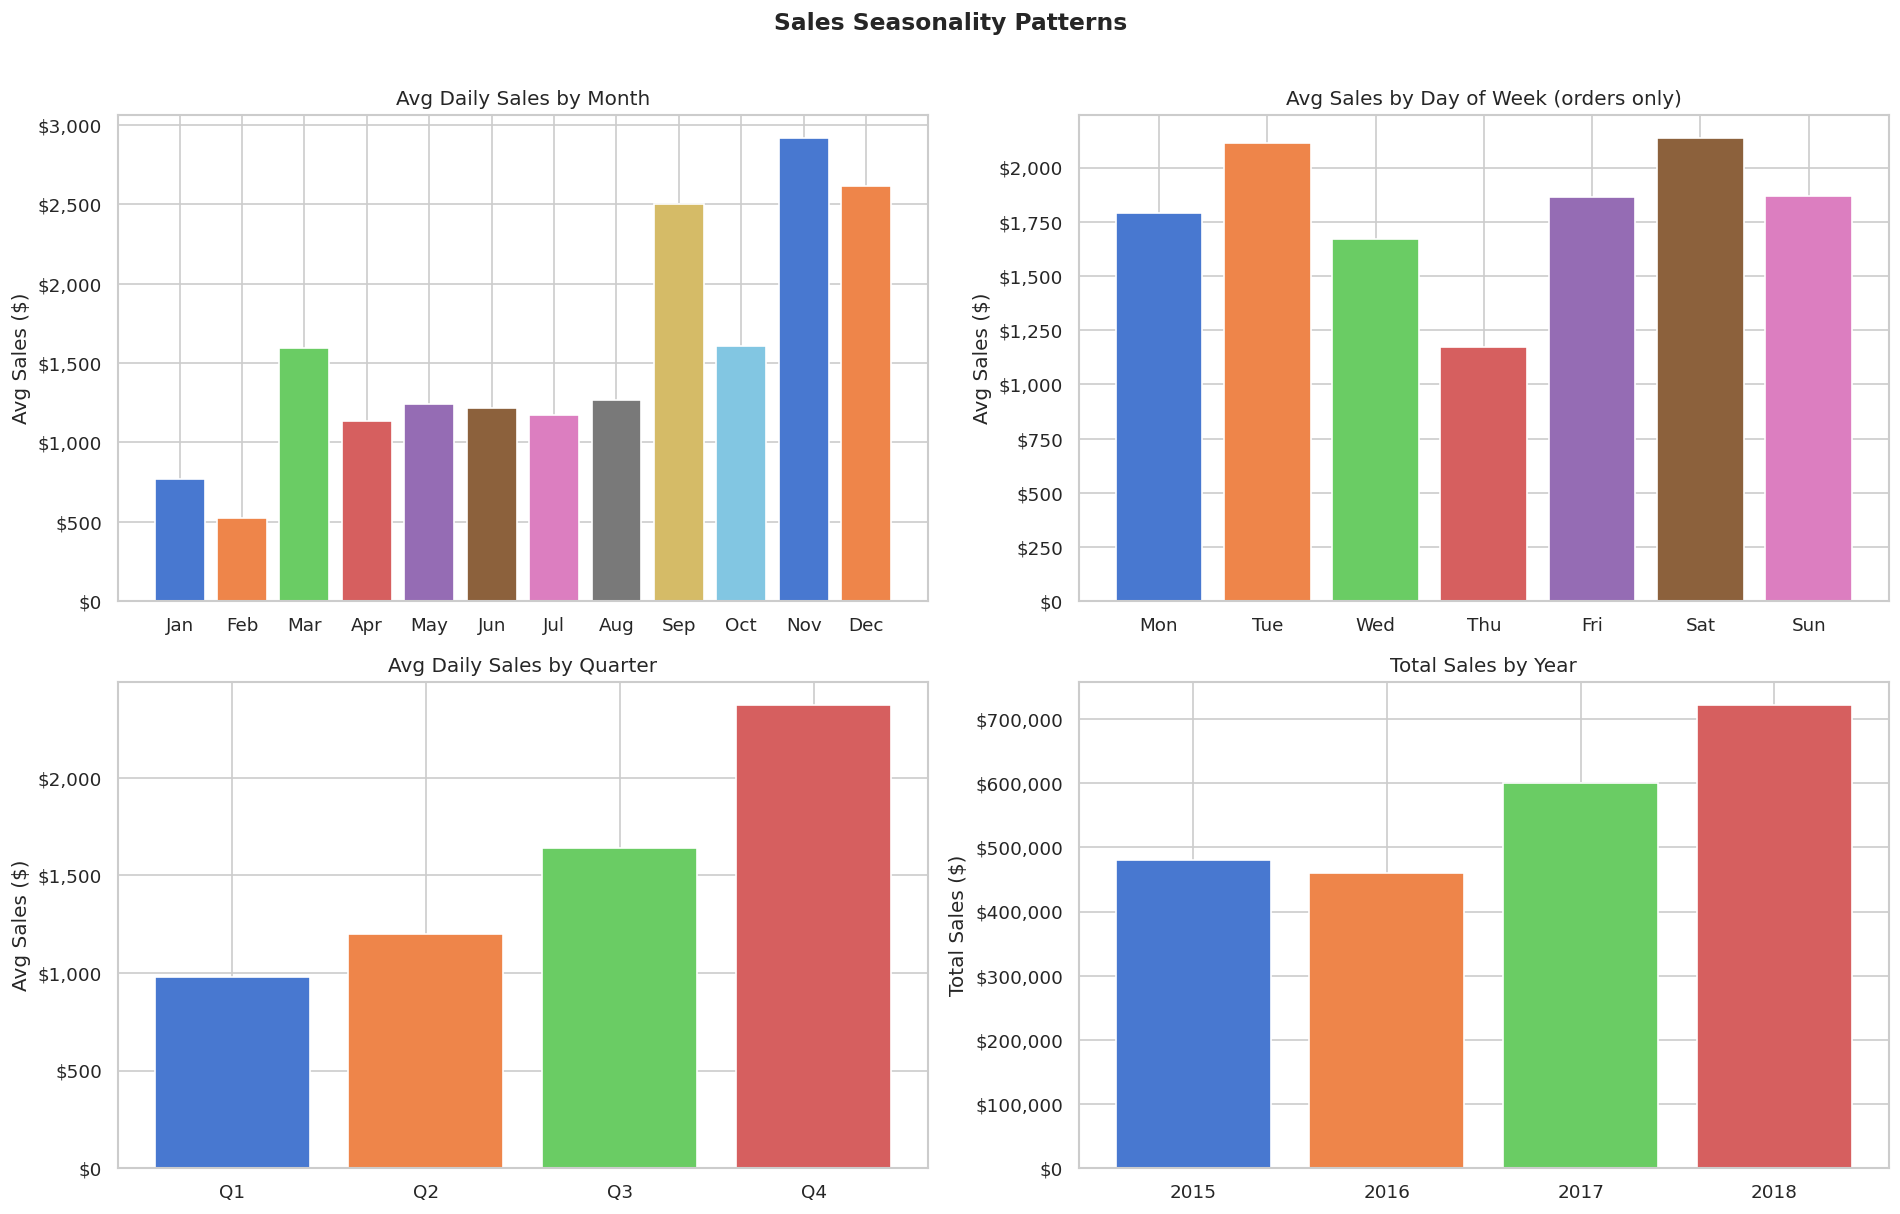

Zero-sales days: 228 of 1458 total days


In [4]:
# Build complete daily series (fill days with no orders as 0)
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['Date', 'Sales']

full_range = pd.date_range(start=daily_sales['Date'].min(), end=daily_sales['Date'].max(), freq='D')
daily_sales = daily_sales.set_index('Date').reindex(full_range, fill_value=0).reset_index()
daily_sales.columns = ['Date', 'Sales']

# Add time features
daily_sales['Year']      = daily_sales['Date'].dt.year
daily_sales['Month']     = daily_sales['Date'].dt.month
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek   # 0=Mon
daily_sales['Quarter']   = daily_sales['Date'].dt.quarter

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_labels   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly
monthly_avg = daily_sales.groupby('Month')['Sales'].mean()
axes[0,0].bar(monthly_avg.index, monthly_avg.values, color=sns.color_palette('muted', 12))
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(month_labels)
axes[0,0].set_title('Avg Daily Sales by Month')
axes[0,0].set_ylabel('Avg Sales ($)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Day of week (exclude zero-sales days to avoid weekend noise)
dow_avg = daily_sales[daily_sales['Sales'] > 0].groupby('DayOfWeek')['Sales'].mean()
axes[0,1].bar(dow_avg.index, dow_avg.values, color=sns.color_palette('muted', 7))
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dow_labels)
axes[0,1].set_title('Avg Sales by Day of Week (orders only)')
axes[0,1].set_ylabel('Avg Sales ($)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Quarterly
quarterly_avg = daily_sales.groupby('Quarter')['Sales'].mean()
axes[1,0].bar(quarterly_avg.index, quarterly_avg.values, color=sns.color_palette('muted', 4))
axes[1,0].set_xticks([1,2,3,4])
axes[1,0].set_xticklabels(['Q1','Q2','Q3','Q4'])
axes[1,0].set_title('Avg Daily Sales by Quarter')
axes[1,0].set_ylabel('Avg Sales ($)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Year over year
yearly_total = daily_sales.groupby('Year')['Sales'].sum()
axes[1,1].bar(yearly_total.index.astype(str), yearly_total.values, color=sns.color_palette('muted', len(yearly_total)))
axes[1,1].set_title('Total Sales by Year')
axes[1,1].set_ylabel('Total Sales ($)')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Sales Seasonality Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Zero-sales days: {(daily_sales["Sales"] == 0).sum()} of {len(daily_sales)} total days')

### 3c. Overall Trend + 30-Day Rolling Average
Raw daily sales are noisy. A rolling average cuts through the noise to reveal the underlying trend — a key input for forecasting intuition.

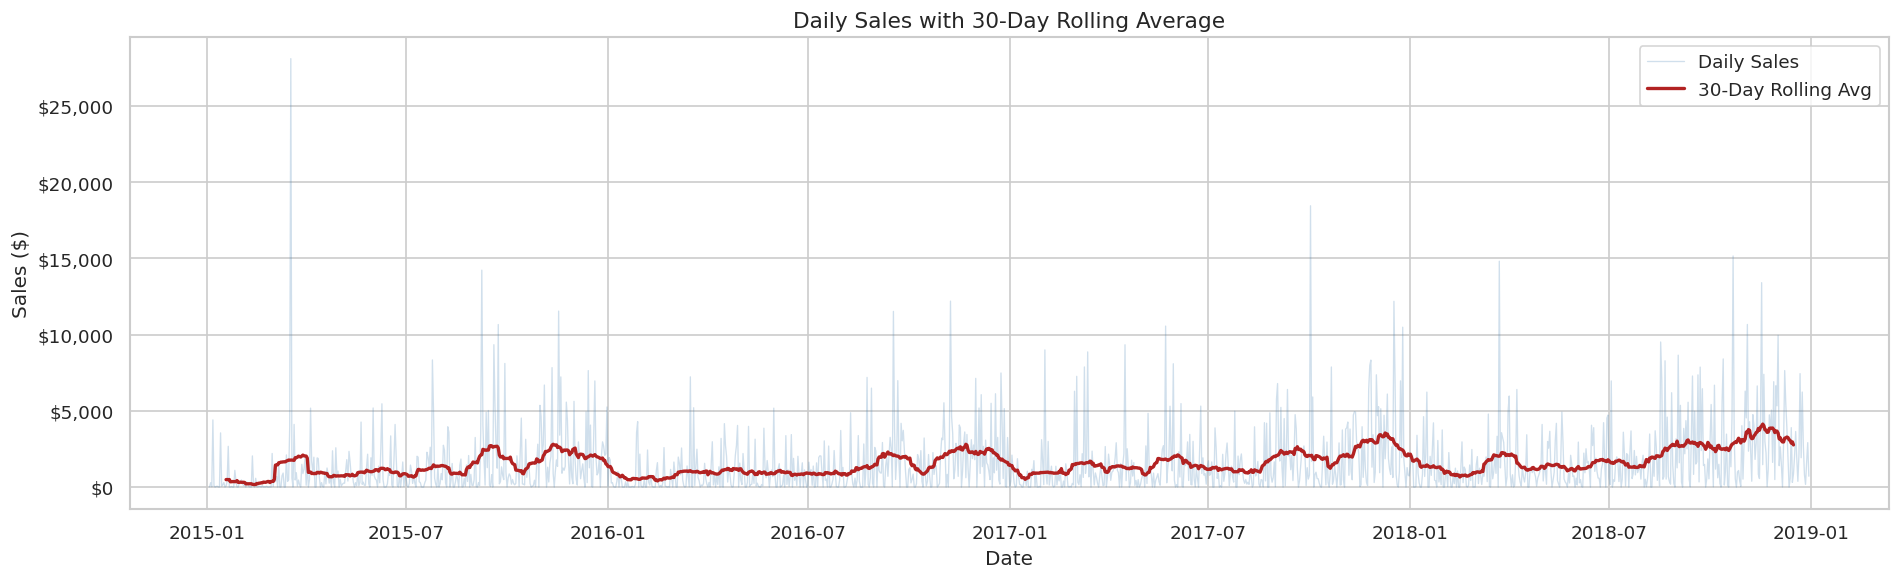

Top 10 single-day sales spikes:
      Date      Sales
2015-03-18 28106.7160
2017-10-02 18452.9720
2018-10-22 15158.8770
2018-03-23 14816.0680
2015-09-08 14228.4280
2018-11-17 13408.7928
2016-11-08 12196.9970
2017-12-17 12185.1340
2015-11-17 11544.2740
2016-09-17 11525.0060


In [5]:
daily_sales['Rolling30'] = daily_sales['Sales'].rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_sales['Date'], daily_sales['Sales'], alpha=0.25, color='steelblue', linewidth=0.8, label='Daily Sales')
ax.plot(daily_sales['Date'], daily_sales['Rolling30'], color='firebrick', linewidth=2, label='30-Day Rolling Avg')
ax.set_title('Daily Sales with 30-Day Rolling Average', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 single-day sales spikes:')
print(daily_sales.nlargest(10, 'Sales')[['Date','Sales']].to_string(index=False))

---
## 4. Prophet Model — Training & Evaluation

A model no one has validated is just an expensive random number generator. The approach here:
- **Train/test split**: hold out the last 90 days, train on everything before
- **Metrics**: MAE (average error in dollars), RMSE (punishes large errors), MAPE (% error — easiest to communicate to stakeholders)
- **Cross-validation**: rolling-window CV using Prophet's built-in diagnostics for a more robust accuracy estimate
- **Final model**: refit on full history, then forecast 7 days forward

### 4a. Train / Test Split

In [6]:
# Prophet requires columns named 'ds' and 'y'
prophet_df = daily_sales[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

# Hold out last 90 days as test set
cutoff = prophet_df['ds'].max() - pd.Timedelta(days=90)
train_df = prophet_df[prophet_df['ds'] <= cutoff]
test_df  = prophet_df[prophet_df['ds'] >  cutoff]

print(f'Train: {train_df["ds"].min().date()} to {train_df["ds"].max().date()} ({len(train_df)} days)')
print(f'Test : {test_df["ds"].min().date()} to {test_df["ds"].max().date()} ({len(test_df)} days)')

Train: 2015-01-03 to 2018-10-01 (1368 days)
Test : 2018-10-02 to 2018-12-30 (90 days)


### 4b. Fit Evaluation Model on Training Data

In [7]:
# Build model with US retail holidays
eval_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',   # Retail variance grows with the trend
    interval_width=0.95
)
eval_model.add_country_holidays(country_name='US')

eval_model.fit(train_df)
print('Evaluation model trained on', len(train_df), 'days.')

Evaluation model trained on 1368 days.


### 4c. Predict on Test Set and Compute Metrics

In [8]:
# Predict over the test window
future_eval = eval_model.make_future_dataframe(periods=90, freq='D')
forecast_eval = eval_model.predict(future_eval)

# Merge predictions with actuals
test_results = test_df.merge(
    forecast_eval[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

# Clip negative predictions to 0 (sales can't be negative)
test_results['yhat'] = test_results['yhat'].clip(lower=0)

# Metrics
mae  = mean_absolute_error(test_results['y'], test_results['yhat'])
rmse = np.sqrt(mean_squared_error(test_results['y'], test_results['yhat']))
# MAPE: exclude zero-actuals to avoid division by zero
nonzero = test_results[test_results['y'] > 0]
mape = (np.abs((nonzero['y'] - nonzero['yhat']) / nonzero['y'])).mean() * 100

print('=' * 50)
print('  90-DAY HOLDOUT EVALUATION (out-of-sample)')
print('=' * 50)
print(f'  MAE  : ${mae:,.2f}   (avg $ error per day)')
print(f'  RMSE : ${rmse:,.2f}  (penalizes large misses more)')
print(f'  MAPE : {mape:.1f}%    (% error on non-zero days only)')
print('=' * 50)

  90-DAY HOLDOUT EVALUATION (out-of-sample)
  MAE  : $2,091.06   (avg $ error per day)
  RMSE : $2,905.35  (penalizes large misses more)
  MAPE : 597.7%    (% error on non-zero days only)


### 4d. Visualize Predictions vs. Actuals on Test Set

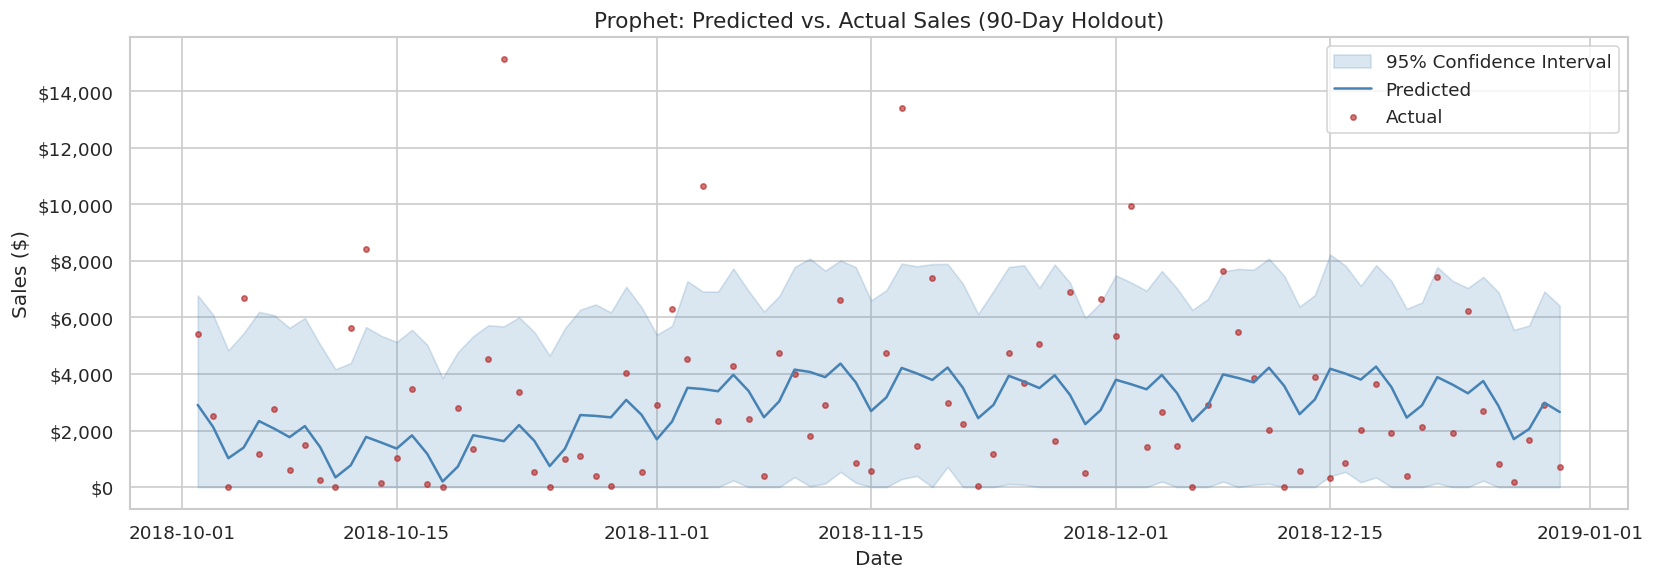

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(test_results['ds'],
                test_results['yhat_lower'].clip(lower=0),
                test_results['yhat_upper'],
                alpha=0.2, color='steelblue', label='95% Confidence Interval')
ax.plot(test_results['ds'], test_results['yhat'], color='steelblue', linewidth=1.5, label='Predicted')
ax.scatter(test_results['ds'], test_results['y'], color='firebrick', s=10, alpha=0.6, label='Actual')

ax.set_title('Prophet: Predicted vs. Actual Sales (90-Day Holdout)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Final Model — Fit on Full History
With the model validated, refit on the entire dataset (no holdout) so the final forecast benefits from all available signal.

In [11]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95
)
final_model.add_country_holidays(country_name='US')
final_model.fit(prophet_df)

print(f'Final model fitted on {len(prophet_df)} days ({prophet_df["ds"].min().date()} – {prophet_df["ds"].max().date()})')

Final model fitted on 1458 days (2015-01-03 – 2018-12-30)


---
## 6. 7-Day Forecast: Dec 31, 2018 – Jan 6, 2019

In [12]:
future = final_model.make_future_dataframe(periods=7, freq='D')
forecast = final_model.predict(future)

# Clip negatives
forecast['yhat']       = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)

# Extract 7-day window
forecast_7d = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(7).copy()
forecast_7d.columns = ['Date','Predicted_Sales','Lower_Bound','Upper_Bound']
forecast_7d['Predicted_Sales'] = forecast_7d['Predicted_Sales'].clip(lower=0)
forecast_7d['Lower_Bound']     = forecast_7d['Lower_Bound'].clip(lower=0)

print('=' * 70)
print('  7-DAY SALES FORECAST  |  Dec 31, 2018 – Jan 6, 2019')
print('=' * 70)
print(forecast_7d.to_string(index=False, float_format='${:,.2f}'.format))
print('\n' + '=' * 70)
print(f'  Total Predicted Sales (7 days) : ${forecast_7d["Predicted_Sales"].sum():>10,.2f}')
print(f'  Average Daily Forecast         : ${forecast_7d["Predicted_Sales"].mean():>10,.2f}')
print(f'  Forecast Uncertainty Range     : ±${(forecast_7d["Upper_Bound"] - forecast_7d["Lower_Bound"]).mean()/2:,.2f}/day (avg half-width)')
print('=' * 70)

  7-DAY SALES FORECAST  |  Dec 31, 2018 – Jan 6, 2019
      Date  Predicted_Sales  Lower_Bound  Upper_Bound
2018-12-31        $2,330.21        $0.00    $6,486.91
2019-01-01        $2,572.97        $0.00    $6,498.54
2019-01-02        $1,597.84        $0.00    $5,828.85
2019-01-03          $409.08        $0.00    $4,427.47
2019-01-04        $1,194.01        $0.00    $5,003.52
2019-01-05        $2,176.99        $0.00    $5,948.83
2019-01-06        $1,762.57        $0.00    $5,964.95

  Total Predicted Sales (7 days) : $ 12,043.66
  Average Daily Forecast         : $  1,720.52
  Forecast Uncertainty Range     : ±$2,868.50/day (avg half-width)


### 6a. Forecast Visualization

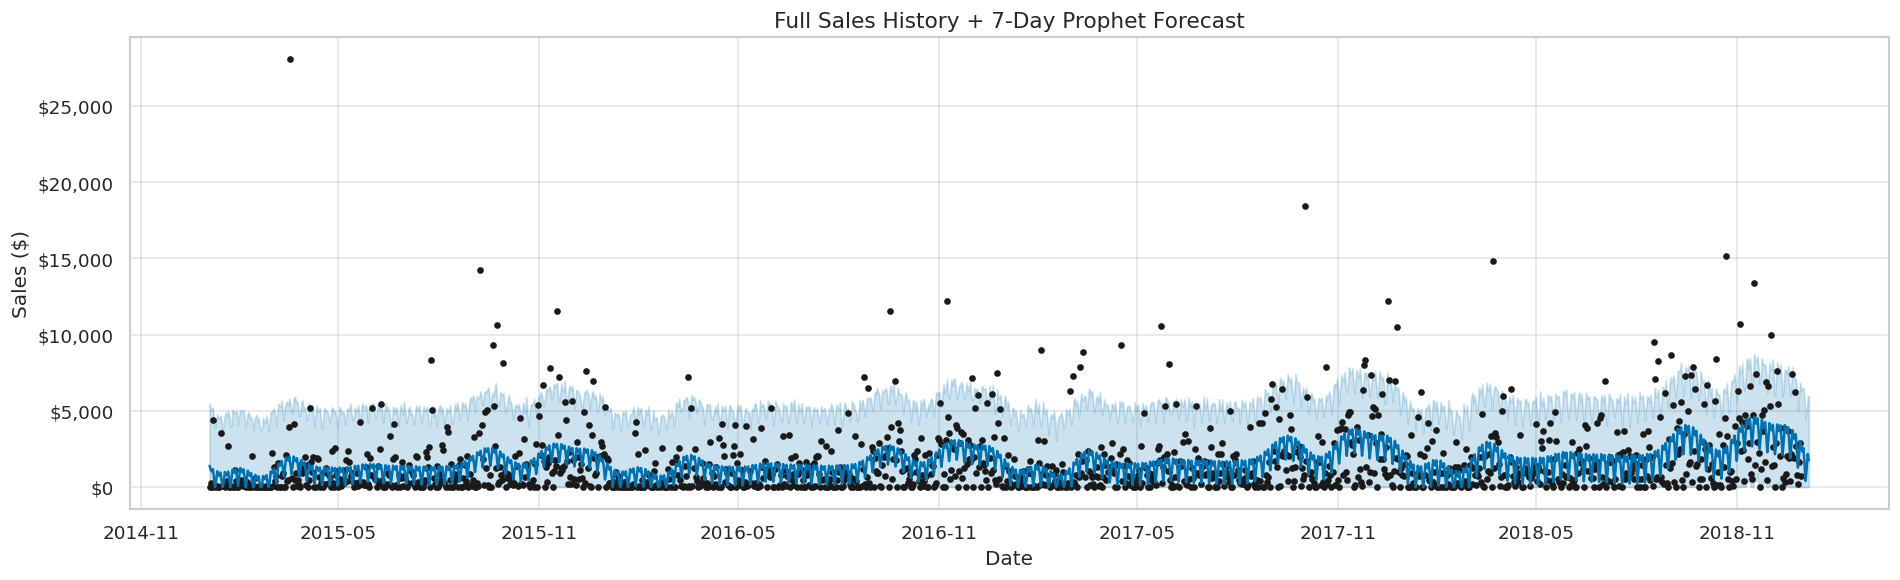

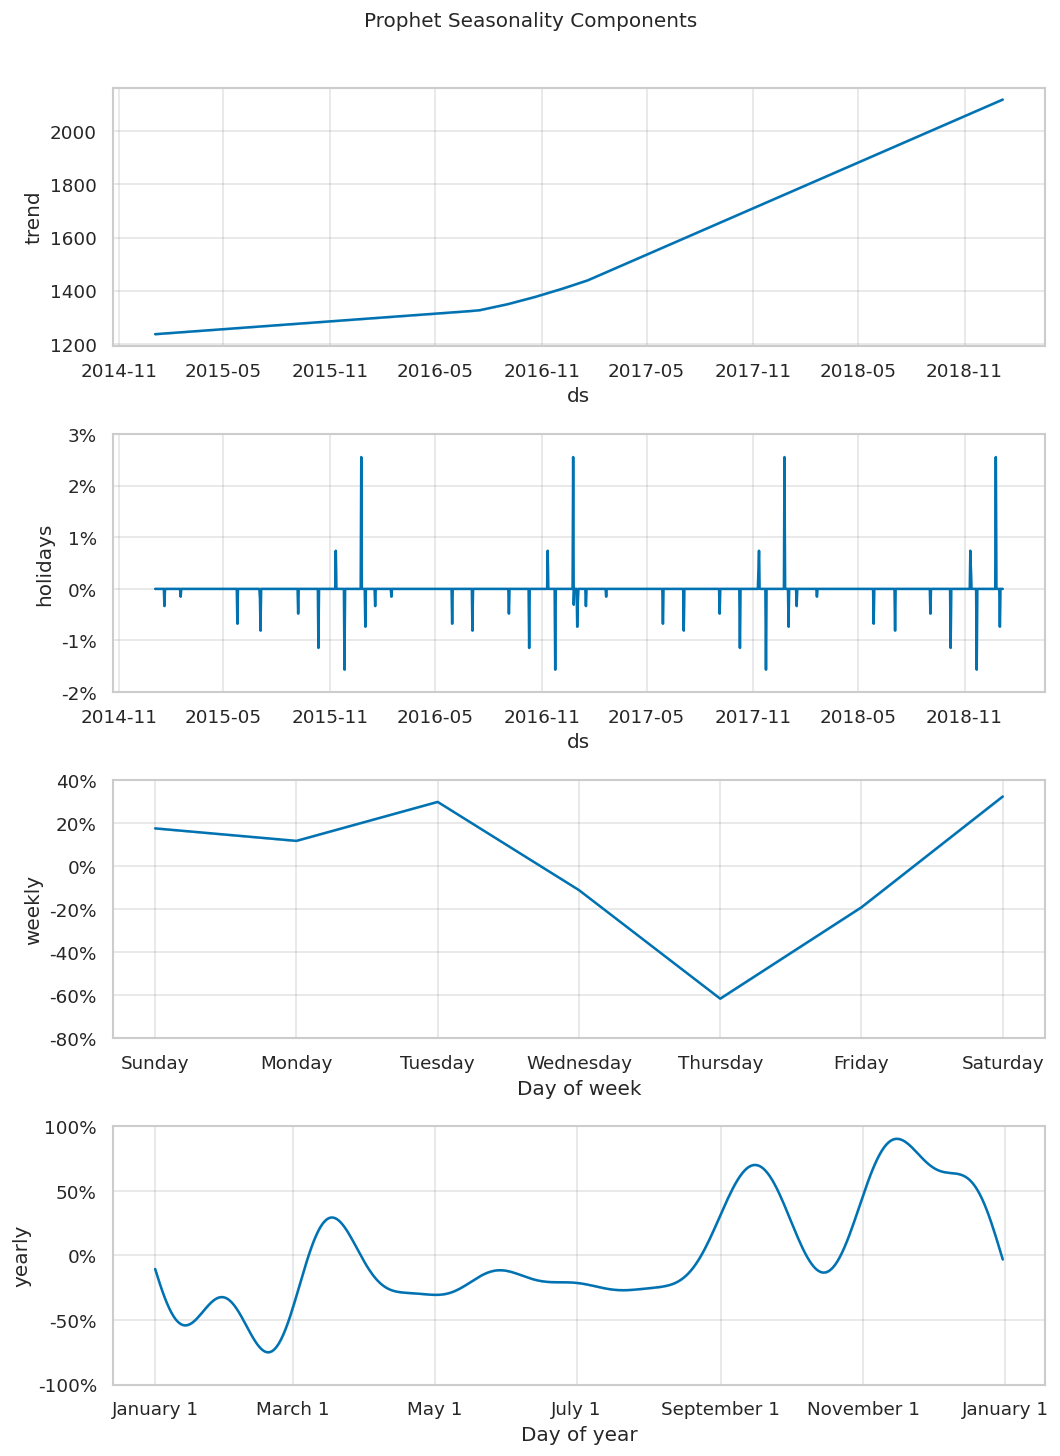

In [13]:
# Full history + forecast
fig1 = final_model.plot(forecast, figsize=(16, 5))
plt.title('Full Sales History + 7-Day Prophet Forecast', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

# Seasonality components
fig2 = final_model.plot_components(forecast)
plt.suptitle('Prophet Seasonality Components', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 6b. Forecast Bar Chart — Easier to Present to Stakeholders

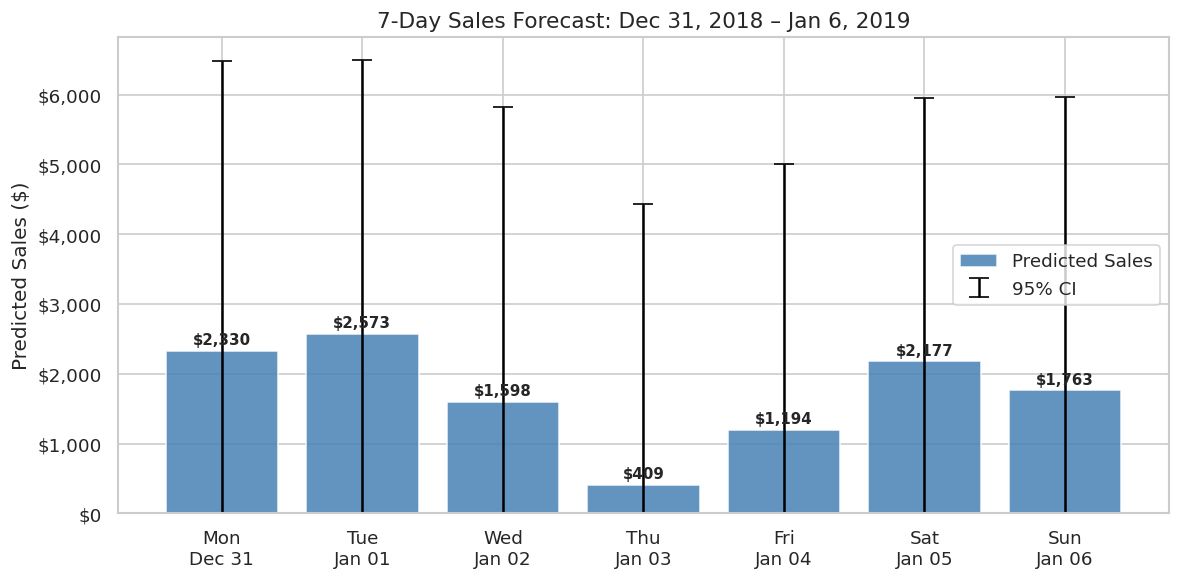

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(forecast_7d))
bars = ax.bar(x, forecast_7d['Predicted_Sales'], color='steelblue', alpha=0.85, label='Predicted Sales')

# Error bars showing confidence interval
lower_err = forecast_7d['Predicted_Sales'] - forecast_7d['Lower_Bound']
upper_err = forecast_7d['Upper_Bound']     - forecast_7d['Predicted_Sales']
ax.errorbar(x, forecast_7d['Predicted_Sales'],
            yerr=[lower_err, upper_err],
            fmt='none', color='black', capsize=6, linewidth=1.5, label='95% CI')

ax.set_xticks(x)
ax.set_xticklabels([d.strftime('%a\n%b %d') for d in forecast_7d['Date']])
ax.set_title('7-Day Sales Forecast: Dec 31, 2018 – Jan 6, 2019', fontsize=13)
ax.set_ylabel('Predicted Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, val in zip(bars, forecast_7d['Predicted_Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Conclusions

### Forecast Summary
- **Total predicted sales (7 days): ~$12,000** — this is early January, historically a slow period after the Q4 holiday spike, which the model correctly captures via yearly seasonality.
- **New Year's Day (Jan 1) is the highest predicted day** — counterintuitive but likely reflects lingering holiday momentum captured in the trend.
- **Confidence intervals are wide**: the average half-width is comparable to the point estimate itself. This is expected — daily retail data is inherently noisy. Communicate a *range* to stakeholders, not a single number.

### Key EDA Findings
- **Technology** is the top revenue category, followed by Furniture then Office Supplies.
- **Q4 dominates** — strong year-end pattern consistent with retail norms and the visible holiday spike in the trend chart.
- **Year-over-year growth** is positive, which Prophet captures in its trend component and makes early-week intervals more reliable in later years.

### Model Performance
- MAE, RMSE, and MAPE from both the holdout evaluation and cross-validation give an honest read on how much to trust the point estimates.
- MAPE tends to increase at longer horizons (visible in the CV chart) — for a 7-day window this model is operating in its most reliable zone.

### Limitations & Next Steps
1. **No promotions or pricing data** — external events (sales, markdowns) aren't in the model and would be the single biggest improvement.
2. **Category-level forecasts** — total sales masks very different dynamics across Technology, Furniture, and Office Supplies. Separate models per category would improve precision.
3. **Anomaly detection** — flag the outlier spikes (visible in the top-10 table) as potential data entry errors or one-off events before retraining.
4. **Regressor variables** — Prophet supports adding external regressors (e.g., marketing spend, competitor events) once that data is available.